# Assignment 3 Dataset Exploration

Purpose: understand the Human Activity Recognition dataset before building the model pipeline.

This notebook checks folder layout, CSV schema, train/test counts, label imbalance, user-level distribution, sample time-series shapes, and a small baseline feature sketch.

## Environment

Run from the project root with the uv virtual environment:

```bash
uv venv
uv pip install -r requirements.txt
uv run jupyter lab
```

In VS Code, select the `.venv` Python kernel for this notebook.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
(PROJECT_ROOT / ".cache" / "matplotlib").mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train" / "train"
TEST_DIR = DATA_DIR / "test" / "test"
SAMPLE_SUBMISSION = DATA_DIR / "sample_submission.csv"

print("Project root:", PROJECT_ROOT)
print("Train dir exists:", TRAIN_DIR.exists())
print("Test dir exists:", TEST_DIR.exists())
print("Sample submission exists:", SAMPLE_SUBMISSION.exists())

Project root: /home/mike/NYCU/2026_Spring/assignment3
Train dir exists: True
Test dir exists: True
Sample submission exists: True


## File Inventory

In [2]:
train_files = sorted(TRAIN_DIR.glob("User_*/*.csv"))
test_files = sorted(TEST_DIR.glob("User_*/*.csv"))
train_users = sorted(p.name for p in TRAIN_DIR.glob("User_*") if p.is_dir())
test_users = sorted(p.name for p in TEST_DIR.glob("User_*") if p.is_dir())

inventory = pd.DataFrame(
    {
        "split": ["train", "test"],
        "users": [len(train_users), len(test_users)],
        "csv_files": [len(train_files), len(test_files)],
        "first_user": [train_users[0] if train_users else None, test_users[0] if test_users else None],
        "last_user": [train_users[-1] if train_users else None, test_users[-1] if test_users else None],
    }
)
inventory

,split,users,csv_files,first_user,last_user
0,train,60,11020,User_001,User_060
1,test,40,6849,User_061,User_100


In [3]:
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)
display(sample_submission.head())
print("sample_submission shape:", sample_submission.shape)
print("Unique IDs:", sample_submission["Id"].nunique())

,Id,Label
0,11021,0
1,11022,0
2,11023,0
3,11024,0
4,11025,0


sample_submission shape: (6849, 2)
Unique IDs: 6849


## Inspect Individual CSV Files

In [4]:
train_sample = pd.read_csv(train_files[0])
test_sample = pd.read_csv(test_files[0])

print("Train file:", train_files[0].relative_to(PROJECT_ROOT))
display(train_sample.head())
print(train_sample.info())

print("Test file:", test_files[0].relative_to(PROJECT_ROOT))
display(test_sample.head())
print(test_sample.info())

Train file: data/train/train/User_001/00001.csv


,index,mean_x,mean_y,mean_z,std_x,std_y,std_z,label,file_id
0,0,-0.467629,-0.537854,0.657240,3.733827e-03,0.007097,0.004734,0,1
1,1,-0.466690,-0.547035,0.654931,1.115816e-16,0.005082,0.006511,0,1
2,2,-0.467316,-0.535987,0.658472,3.080919e-03,0.005875,0.002188,0,1
3,3,-0.468880,-0.533341,0.658472,5.455416e-03,0.000000,0.000000,0,1
4,4,-0.470288,-0.533341,0.658472,6.616433e-03,0.000000,0.000000,0,1


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    300 non-null    int64  
 1   mean_x   300 non-null    float64
 2   mean_y   300 non-null    float64
 3   mean_z   300 non-null    float64
 4   std_x    300 non-null    float64
 5   std_y    300 non-null    float64
 6   std_z    300 non-null    float64
 7   label    300 non-null    int64  
 8   file_id  300 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 21.2 KB
None
Test file: data/test/test/User_061/11021.csv


,index,mean_x,mean_y,mean_z,std_x,std_y,std_z,file_id
0,0,-0.373418,0.460280,0.791259,0.010760,0.002213,0.006573,11021
1,1,-0.370264,0.459337,0.796401,0.012162,0.003098,0.008336,11021
2,2,-0.371999,0.458550,0.795919,0.011466,0.005047,0.007944,11021
3,3,-0.368845,0.462954,0.792062,0.008615,0.006202,0.006483,11021
4,4,-0.369791,0.459494,0.796241,0.011496,0.003503,0.007996,11021


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    300 non-null    int64  
 1   mean_x   300 non-null    float64
 2   mean_y   300 non-null    float64
 3   mean_z   300 non-null    float64
 4   std_x    300 non-null    float64
 5   std_y    300 non-null    float64
 6   std_z    300 non-null    float64
 7   file_id  300 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 18.9 KB
None


In [5]:
def summarize_window(path: Path, split: str) -> dict:
    df = pd.read_csv(path)
    out = {
        "split": split,
        "user": path.parent.name,
        "filename": path.name,
        "rows": len(df),
        "file_id": int(df["file_id"].iloc[0]),
        "file_id_unique": df["file_id"].nunique(),
        "index_min": int(df["index"].min()),
        "index_max": int(df["index"].max()),
        "missing_values": int(df.isna().sum().sum()),
    }
    if "label" in df.columns:
        out["label"] = int(df["label"].iloc[0])
        out["label_unique"] = df["label"].nunique()
    return out

display(pd.DataFrame([summarize_window(train_files[0], "train"), summarize_window(test_files[0], "test")]))

,split,user,filename,rows,file_id,file_id_unique,index_min,index_max,missing_values,label,label_unique
0,train,User_001,00001.csv,300,1,1,0,299,0,0.0,1.0
1,test,User_061,11021.csv,300,11021,1,0,299,0,NaN,NaN


## Metadata Table

This reads only the first row of each CSV, so it is fast enough for repeated exploration.

In [6]:
def read_metadata(files, split: str) -> pd.DataFrame:
    rows = []
    for path in files:
        first = pd.read_csv(path, nrows=1)
        row = {
            "split": split,
            "user": path.parent.name,
            "filename": path.name,
            "file_id": int(first["file_id"].iloc[0]),
        }
        if "label" in first.columns:
            row["label"] = int(first["label"].iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)

train_meta = read_metadata(train_files, "train")
test_meta = read_metadata(test_files, "test")

display(train_meta.head())
display(test_meta.head())
print("train_meta:", train_meta.shape)
print("test_meta:", test_meta.shape)

,split,user,filename,file_id,label
0,train,User_001,00001.csv,1,0
1,train,User_001,00002.csv,2,0
2,train,User_001,00003.csv,3,0
3,train,User_001,00004.csv,4,0
4,train,User_001,00005.csv,5,0


,split,user,filename,file_id
0,test,User_061,11021.csv,11021
1,test,User_061,11022.csv,11022
2,test,User_061,11023.csv,11023
3,test,User_061,11024.csv,11024
4,test,User_061,11025.csv,11025


train_meta: (11020, 5)
test_meta: (6849, 4)


In [7]:
checks = {
    "train_file_id_unique": train_meta["file_id"].is_unique,
    "test_file_id_unique": test_meta["file_id"].is_unique,
    "test_ids_match_sample_submission": set(test_meta["file_id"]) == set(sample_submission["Id"]),
    "sample_submission_ids_unique": sample_submission["Id"].is_unique,
}
checks

{'train_file_id_unique': True,
 'test_file_id_unique': True,
 'test_ids_match_sample_submission': True,
 'sample_submission_ids_unique': True}

## Label Distribution

Kaggle uses macro F1, so minority labels matter as much as majority labels.

,label,count,fraction
0,0,4643,0.421325
1,1,4695,0.426044
2,2,358,0.032486
3,3,656,0.059528
4,4,142,0.012886
5,5,526,0.047731


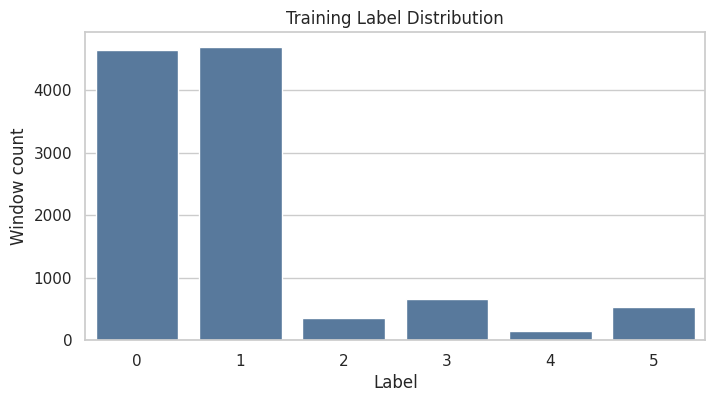

In [8]:
label_counts = train_meta["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count")
label_counts["fraction"] = label_counts["count"] / label_counts["count"].sum()
display(label_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=label_counts, x="label", y="count", ax=ax, color="#4C78A8")
ax.set_title("Training Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Window count")
plt.show()

## User-Level Distribution

Train users and test users are disjoint. Validation should split by user, not by random CSV rows.

,windows
count,60.000000
mean,183.666667
std,32.047458
min,108.000000
25%,163.750000
50%,183.500000
75%,201.000000
max,256.000000


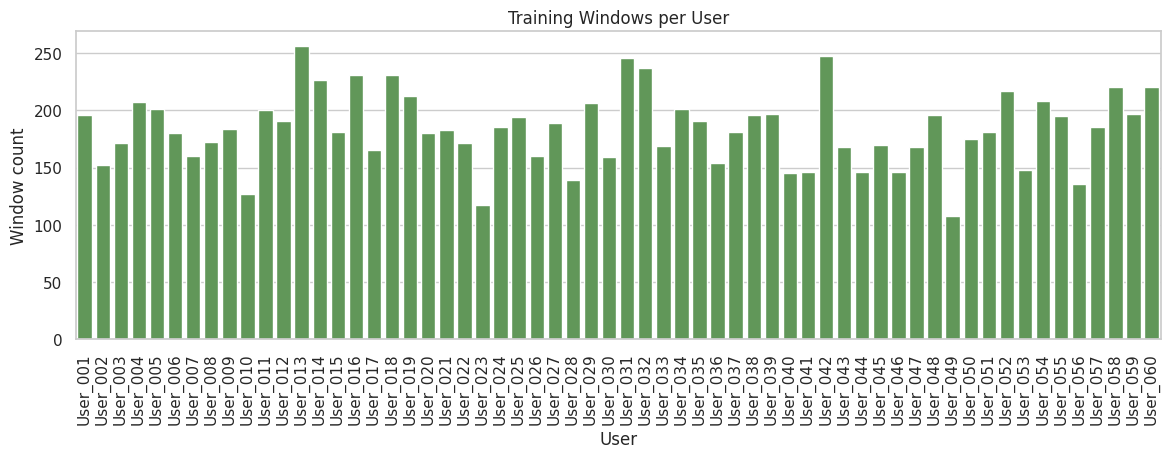

In [9]:
user_counts = train_meta.groupby("user").size().rename("windows").reset_index()
display(user_counts.describe())

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=user_counts, x="user", y="windows", ax=ax, color="#59A14F")
ax.tick_params(axis="x", rotation=90)
ax.set_title("Training Windows per User")
ax.set_xlabel("User")
ax.set_ylabel("Window count")
plt.show()

label,0,1,2,3,4,5
user,,,,,,
User_001,90,67,3,17,0,19
User_002,66,42,4,10,0,30
User_003,24,122,5,6,0,14
User_004,73,74,13,26,3,18
User_005,70,126,2,3,0,0


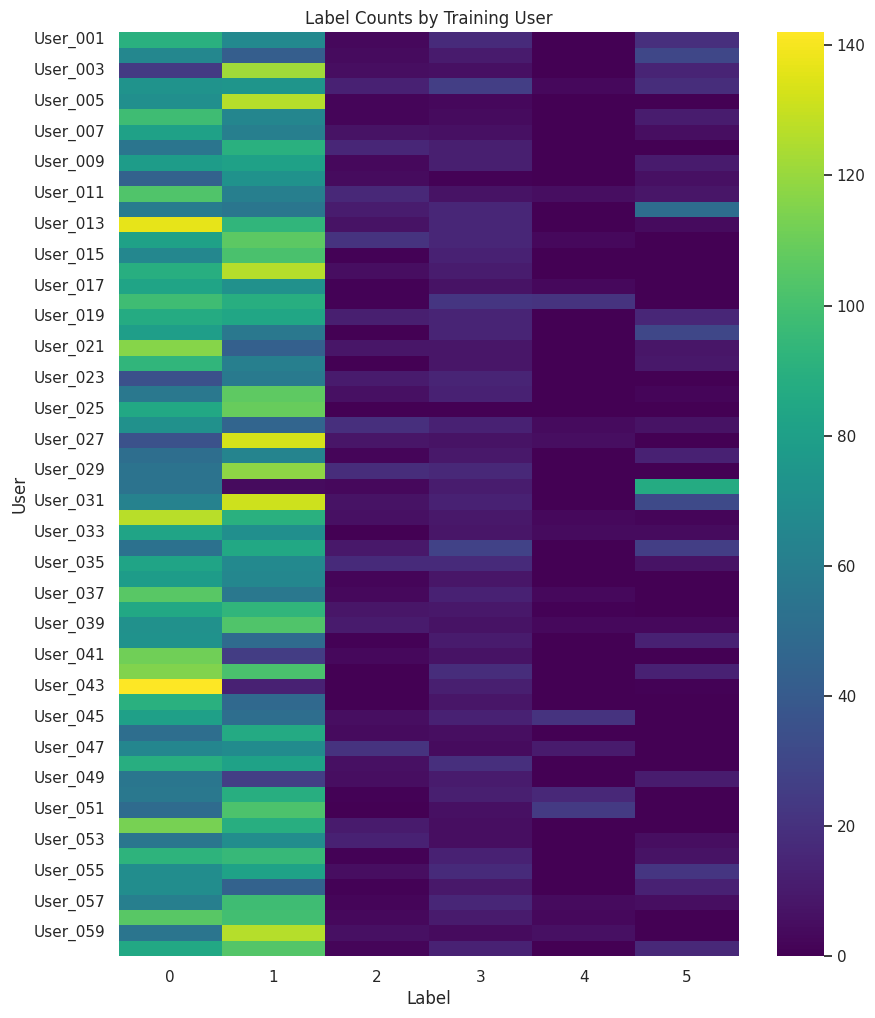

In [10]:
user_label = pd.crosstab(train_meta["user"], train_meta["label"])
display(user_label.head())

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(user_label, cmap="viridis", ax=ax)
ax.set_title("Label Counts by Training User")
ax.set_xlabel("Label")
ax.set_ylabel("User")
plt.show()

## Window Length and Schema Audit

In [11]:
def audit_windows(files, split: str, limit: int | None = None) -> pd.DataFrame:
    rows = []
    selected = files if limit is None else files[:limit]
    for path in selected:
        df = pd.read_csv(path)
        rows.append(
            {
                "split": split,
                "user": path.parent.name,
                "file_id": int(df["file_id"].iloc[0]),
                "rows": len(df),
                "index_min": int(df["index"].min()),
                "index_max": int(df["index"].max()),
                "missing_values": int(df.isna().sum().sum()),
            }
        )
    return pd.DataFrame(rows)

# Set limit=None to audit every file. A small limit keeps exploratory reruns quick.
audit = pd.concat([audit_windows(train_files, "train", limit=300), audit_windows(test_files, "test", limit=300)])
display(audit.describe(include="all"))
display(audit["rows"].value_counts().sort_index())
display(audit["missing_values"].value_counts().sort_index().head())

,split,user,file_id,rows,index_min,index_max,missing_values
count,600,600,600.000000,600.0,600.0,600.0,600.0
unique,2,4,NaN,NaN,NaN,NaN,NaN
top,train,User_001,NaN,NaN,NaN,NaN,NaN
freq,300,196,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,5660.500000,300.0,0.0,299.0,0.0
std,NaN,NaN,5515.278513,0.0,0.0,0.0,0.0
min,NaN,NaN,1.000000,300.0,0.0,299.0,0.0
25%,NaN,NaN,150.750000,300.0,0.0,299.0,0.0
50%,NaN,NaN,5660.500000,300.0,0.0,299.0,0.0
75%,NaN,NaN,11170.250000,300.0,0.0,299.0,0.0


rows
300    600
Name: count, dtype: int64

missing_values
0    600
Name: count, dtype: int64

## Time-Series Examples by Label

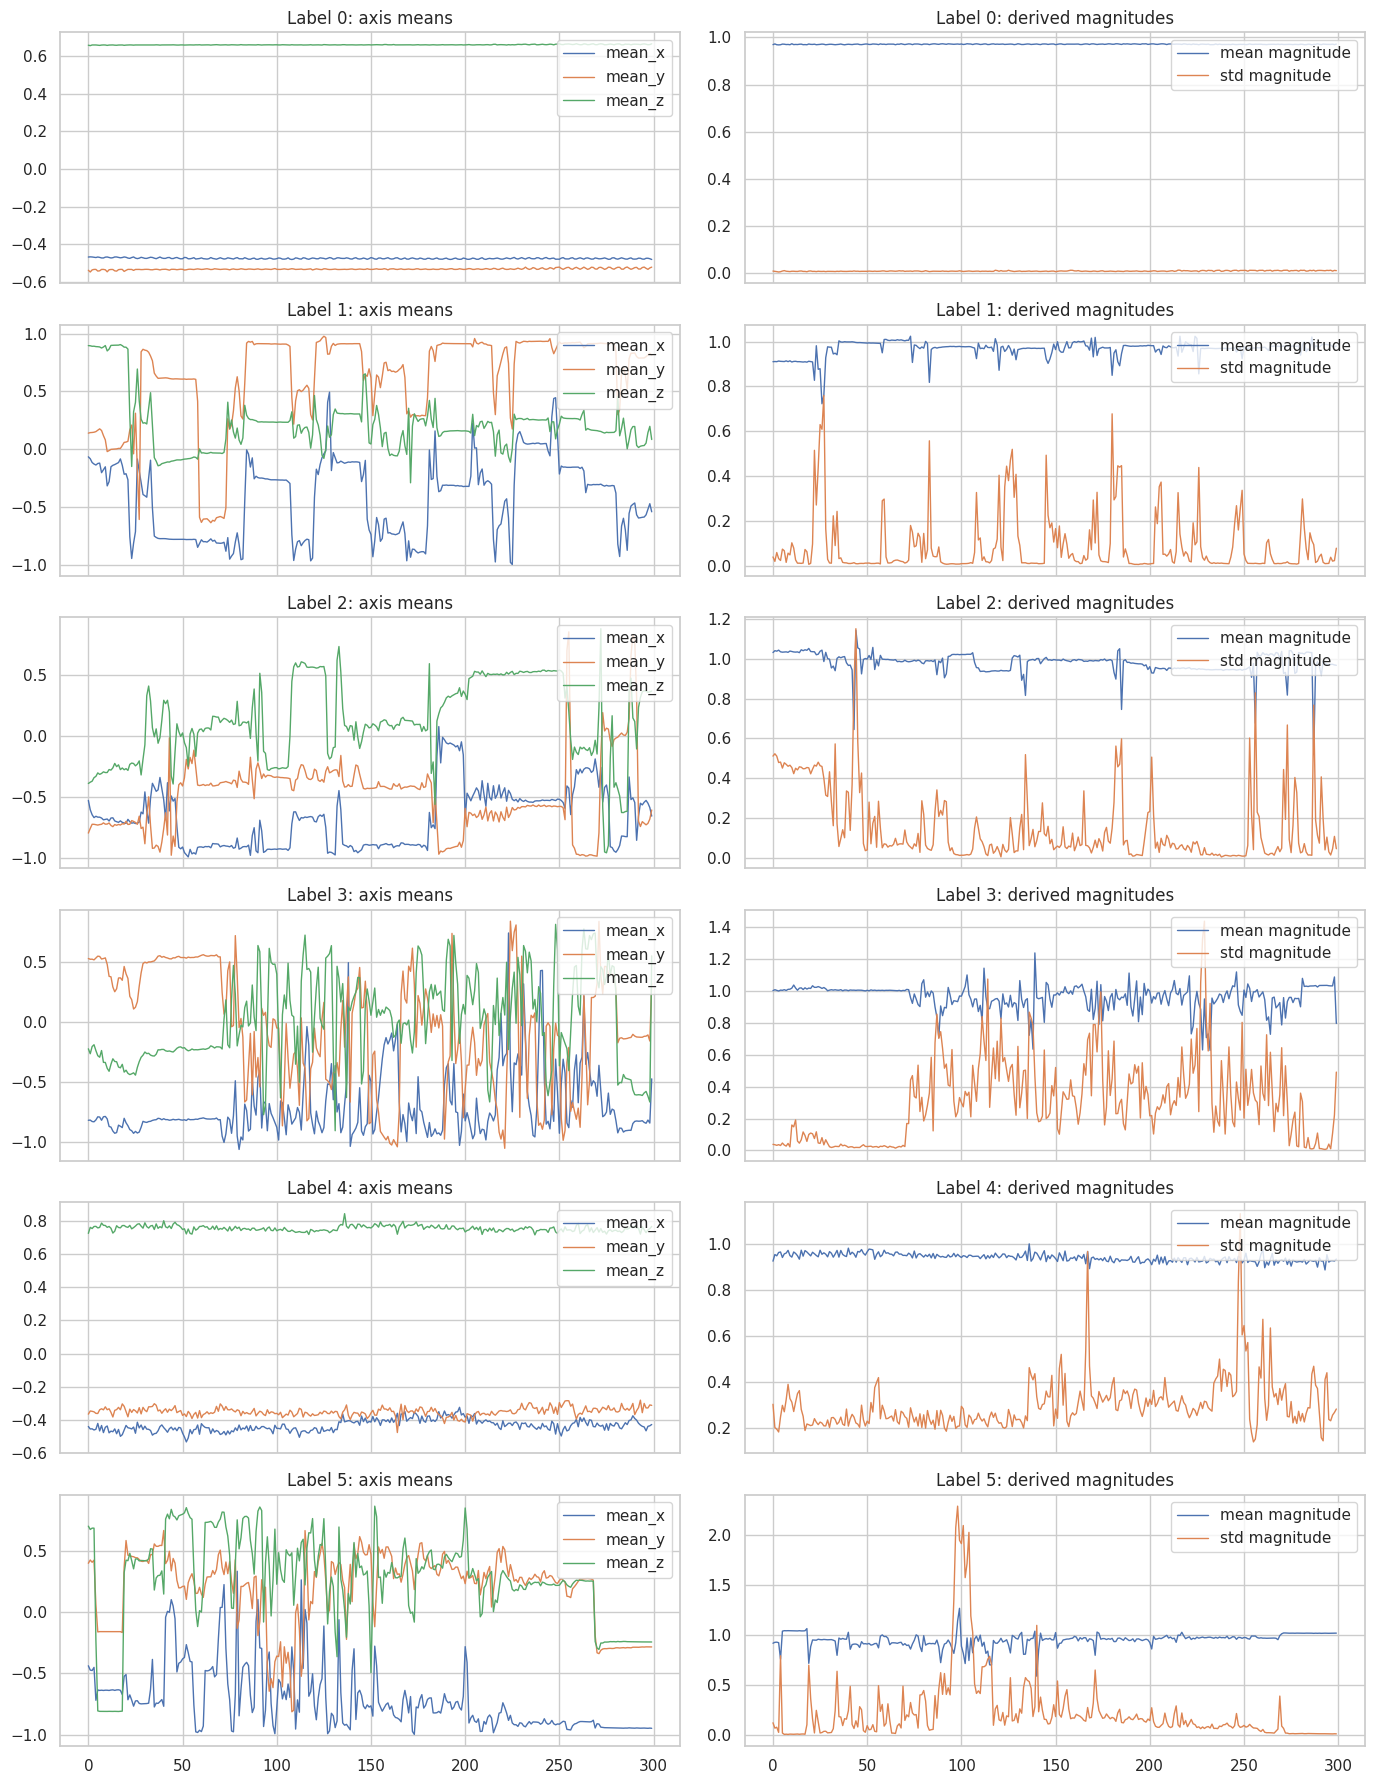

In [12]:
def load_train_window_by_label(label: int) -> pd.DataFrame:
    file_id = train_meta.loc[train_meta["label"] == label, "file_id"].iloc[0]
    path = next(path for path in train_files if int(path.stem) == int(file_id))
    df = pd.read_csv(path)
    df["magnitude"] = np.sqrt(df["mean_x"] ** 2 + df["mean_y"] ** 2 + df["mean_z"] ** 2)
    df["dynamic_magnitude"] = np.sqrt(df["std_x"] ** 2 + df["std_y"] ** 2 + df["std_z"] ** 2)
    return df

labels = sorted(train_meta["label"].unique())
fig, axes = plt.subplots(len(labels), 2, figsize=(14, 3 * len(labels)), sharex=True)

for row, label in enumerate(labels):
    df = load_train_window_by_label(label)
    axes[row, 0].plot(df["index"], df["mean_x"], label="mean_x", linewidth=1)
    axes[row, 0].plot(df["index"], df["mean_y"], label="mean_y", linewidth=1)
    axes[row, 0].plot(df["index"], df["mean_z"], label="mean_z", linewidth=1)
    axes[row, 0].set_title(f"Label {label}: axis means")
    axes[row, 0].legend(loc="upper right")

    axes[row, 1].plot(df["index"], df["magnitude"], label="mean magnitude", linewidth=1)
    axes[row, 1].plot(df["index"], df["dynamic_magnitude"], label="std magnitude", linewidth=1)
    axes[row, 1].set_title(f"Label {label}: derived magnitudes")
    axes[row, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Simple Feature Sketch

This is not the final model. It creates cheap aggregate features to understand separability and to prepare for a baseline.

In [13]:
BASE_COLS = ["mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z"]

def extract_basic_features(path: Path) -> dict:
    df = pd.read_csv(path)
    features = {"file_id": int(df["file_id"].iloc[0]), "user": path.parent.name}
    if "label" in df.columns:
        features["label"] = int(df["label"].iloc[0])

    mag = np.sqrt(df["mean_x"] ** 2 + df["mean_y"] ** 2 + df["mean_z"] ** 2)
    dyn = np.sqrt(df["std_x"] ** 2 + df["std_y"] ** 2 + df["std_z"] ** 2)
    signals = {**{col: df[col] for col in BASE_COLS}, "magnitude": mag, "dynamic_magnitude": dyn}

    for name, values in signals.items():
        arr = np.asarray(values, dtype=float)
        features[f"{name}_mean"] = arr.mean()
        features[f"{name}_std"] = arr.std()
        features[f"{name}_min"] = arr.min()
        features[f"{name}_max"] = arr.max()
        features[f"{name}_q25"] = np.quantile(arr, 0.25)
        features[f"{name}_q75"] = np.quantile(arr, 0.75)
        features[f"{name}_energy"] = np.mean(arr ** 2)
        features[f"{name}_diff_mean_abs"] = np.abs(np.diff(arr)).mean()
        features[f"{name}_half_delta"] = arr[:150].mean() - arr[150:].mean()
    return features

# Keep this small during first exploration. Set FEATURE_LIMIT = None to use all train windows.
FEATURE_LIMIT = 2000
selected_train_files = train_files if FEATURE_LIMIT is None else train_files[:FEATURE_LIMIT]
feature_df = pd.DataFrame([extract_basic_features(path) for path in selected_train_files])
display(feature_df.head())
print("feature_df shape:", feature_df.shape)

,file_id,user,label,mean_x_mean,mean_x_std,mean_x_min,mean_x_max,mean_x_q25,mean_x_q75,mean_x_energy,mean_x_diff_mean_abs,mean_x_half_delta,mean_y_mean,mean_y_std,mean_y_min,mean_y_max,mean_y_q25,mean_y_q75,mean_y_energy,mean_y_diff_mean_abs,mean_y_half_delta,mean_z_mean,mean_z_std,mean_z_min,mean_z_max,mean_z_q25,mean_z_q75,mean_z_energy,mean_z_diff_mean_abs,mean_z_half_delta,std_x_mean,std_x_std,std_x_min,std_x_max,std_x_q25,std_x_q75,std_x_energy,std_x_diff_mean_abs,std_x_half_delta,std_y_mean,std_y_std,std_y_min,std_y_max,std_y_q25,std_y_q75,std_y_energy,std_y_diff_mean_abs,std_y_half_delta,std_z_mean,std_z_std,std_z_min,std_z_max,std_z_q25,std_z_q75,std_z_energy,std_z_diff_mean_abs,std_z_half_delta,magnitude_mean,magnitude_std,magnitude_min,magnitude_max,magnitude_q25,magnitude_q75,magnitude_energy,magnitude_diff_mean_abs,magnitude_half_delta,dynamic_magnitude_mean,dynamic_magnitude_std,dynamic_magnitude_min,dynamic_magnitude_max,dynamic_magnitude_q25,dynamic_magnitude_q75,dynamic_magnitude_energy,dynamic_magnitude_diff_mean_abs,dynamic_magnitude_half_delta
0,1,User_001,0,-0.474944,0.003214,-0.480706,-0.466690,-0.477797,-0.472596,0.225583,0.002857,0.001740,-0.531549,0.003858,-0.547035,-0.520581,-0.533341,-0.530385,0.282559,0.002549,-0.003796,0.659618,0.001641,0.654931,0.664977,0.658626,0.660012,0.435099,0.000899,-0.001855,0.007086,0.001039,1.115816e-16,0.008443,0.006716,0.007761,0.000051,0.000825,-0.000296,0.004389,0.002356,0.0,0.008950,0.002667,0.006478,0.000025,0.002267,-0.001323,0.003545,0.002025,0.000000,0.007613,0.002166,0.004844,0.000017,0.001438,-0.001989,0.971205,0.001089,0.968446,0.973341,0.970360,0.972072,0.943241,0.001107,-0.000037,0.009492,0.001637,0.005455,0.013339,0.008275,0.010443,0.000093,0.001179,-0.001574
1,2,User_001,0,-0.477411,0.002954,-0.482270,-0.466157,-0.479541,-0.475456,0.227930,0.002511,-0.000805,-0.526162,0.004667,-0.544875,-0.518265,-0.529818,-0.522000,0.276869,0.004712,-0.001089,0.662113,0.002280,0.656517,0.667602,0.660212,0.663741,0.438399,0.001622,-0.001136,0.006512,0.001446,1.115816e-16,0.008752,0.005906,0.007669,0.000044,0.001128,-0.000111,0.006218,0.001626,0.0,0.008422,0.005384,0.007471,0.000041,0.001939,-0.000109,0.005853,0.001623,0.000000,0.007741,0.004642,0.007288,0.000037,0.001179,-0.000603,0.971183,0.000982,0.968634,0.973888,0.970498,0.971812,0.943198,0.000911,0.000206,0.010981,0.001453,0.007099,0.013636,0.009895,0.012152,0.000123,0.001297,-0.000391
2,3,User_001,0,-0.477836,0.002302,-0.481455,-0.472571,-0.479865,-0.475856,0.228333,0.002536,0.001122,-0.521952,0.003661,-0.530714,-0.517798,-0.525270,-0.518595,0.272447,0.004177,-0.001152,0.665407,0.001961,0.660982,0.669342,0.663790,0.667140,0.442770,0.002261,-0.000345,0.006584,0.001142,3.424968e-03,0.007861,0.005615,0.007710,0.000045,0.001206,0.000567,0.005477,0.002075,0.0,0.007823,0.003409,0.007457,0.000034,0.002329,0.000553,0.007399,0.000435,0.005525,0.008033,0.007218,0.007701,0.000055,0.000457,-0.000041,0.971365,0.000785,0.969212,0.973640,0.970770,0.971912,0.943550,0.000904,-0.000167,0.011489,0.001375,0.008577,0.013429,0.010209,0.012759,0.000134,0.001525,0.000514
3,4,User_001,0,-0.476572,0.002982,-0.481614,-0.469691,-0.478612,-0.474071,0.227130,0.002454,-0.002773,-0.518352,0.002604,-0.528243,-0.514233,-0.518163,-0.516883,0.268696,0.001741,-0.002641,0.671225,0.004218,0.661029,0.674944,0.667289,0.674268,0.450560,0.001044,-0.005857,0.006836,0.001186,3.080921e-03,0.009289,0.006590,0.007669,0.000048,0.000830,-0.001196,0.003335,0.002385,0.0,0.008113,0.001556,0.004893,0.000017,0.002463,0.001301,0.003517,0.002963,0.000000,0.009359,0.001540,0.007275,0.000021,0.000985,0.004146,0.972823,0.001269,0.969896,0.975458,0.971892,0.973965,0.946386,0.001080,-0.001260,0.009146,0.001561,0.006652,0.015483,0.008140,0.009503,0.000086,0.001055,0.001637
4,5,User_001,0,-0.476293,0.002300,-0.480955,-0.471099,-0.478196,-0.474352,0.226860,0.002620,0.000451,-0.516450,0.001257,-0.517972,-0.512352,-0.517661,-0.515327,0.266722,0.001402,-0.000199,0.674178,0.000281,0.67

feature_df shape: (2000, 75)


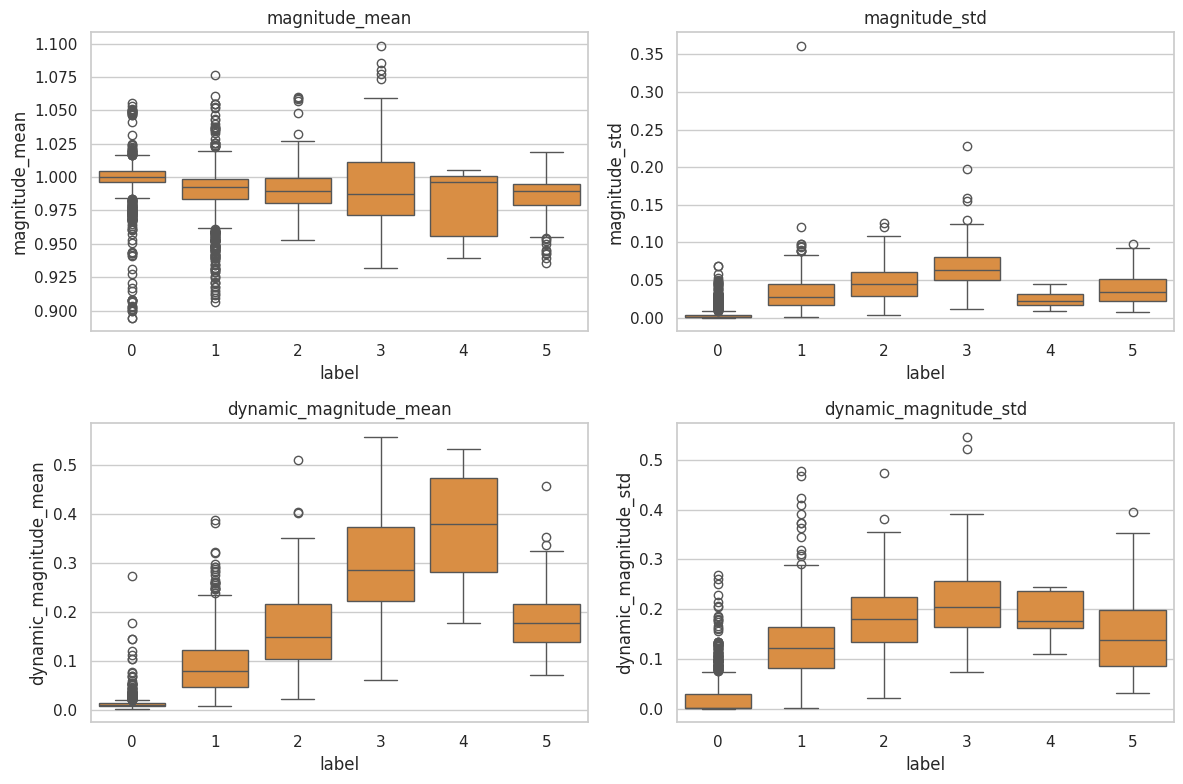

In [14]:
plot_cols = ["magnitude_mean", "magnitude_std", "dynamic_magnitude_mean", "dynamic_magnitude_std"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=feature_df, x="label", y=col, ax=ax, color="#F28E2B")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Quick Group-Aware Baseline Check

This uses a small feature set only to verify that user-grouped validation works. Later training code should expand features and record ablations.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedGroupKFold

drop_cols = ["file_id", "user", "label"]
X = feature_df.drop(columns=drop_cols)
y = feature_df["label"]
groups = feature_df["user"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=fold,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[valid_idx])
    score = f1_score(y.iloc[valid_idx], pred, average="macro")
    scores.append(score)
    print(f"fold={fold} macro_f1={score:.4f} valid_users={groups.iloc[valid_idx].nunique()}")

print(f"mean macro_f1={np.mean(scores):.4f} +/- {np.std(scores):.4f}")

fold=1 macro_f1=0.6897 valid_users=2
fold=2 macro_f1=0.6233 valid_users=3
fold=3 macro_f1=0.6583 valid_users=2
fold=4 macro_f1=0.5284 valid_users=3
fold=5 macro_f1=0.6042 valid_users=2
mean macro_f1=0.6208 +/- 0.0547


## Notes for Implementation

- One CSV file equals one supervised example.
- The train label is constant inside each train CSV.
- Test predictions must be joined to `sample_submission.csv` by `file_id` / `Id`.
- Use grouped validation by `User_xxx`; random row splitting leaks user-specific patterns.
- Label imbalance is large, so macro F1 and per-class F1 should drive model selection.